In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import os
import tensorflow as tf

2026-03-02 11:46:53.225209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772480813.441857 1052027 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772480813.498579 1052027 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772480813.923609 1052027 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772480813.923636 1052027 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772480813.923640 1052027 computation_placer.cc:177] computation placer alr

In [2]:
print("here")

here


In [3]:
# minorized reference
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_ref_mean.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    ref_d = file['density'][:]
#print(ref_d)
print(ref_d.shape)




(64, 64, 64)


In [4]:
def D_JS(p1,p2,tol=1e-16):
    p1=p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [5]:
data = np.load("/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/Data_Gen/NO_DFT/Synthetic_Transformed_N1000000_MD.npz")


In [6]:
print(data['x_train'].shape)

(10000, 64, 64, 64)


In [7]:
x_train = data['x_train']
x_val   = data['x_val']
y_train = data['y_train']
y_val   = data['y_val']
n_samples = 10**6

x_train = x_train[..., np.newaxis]
x_val   = x_val[..., np.newaxis]

y_train = y_train[..., np.newaxis]
y_val   = y_val[..., np.newaxis]
data = 0


In [8]:
dft_path ='/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5'
with h5py.File(dft_path, 'r') as file:
    dft_d = file['density'][:]
# 1. Get the residual map (what the network sees)
residual_map = x_train[0,:,:,:,0]
print(f"Residual Sum: {np.sum(residual_map):.2f} (Expected: close to 0, not 50)")

# 2. Inverse Transform to get Real Density
# Formula: Density = (Residual * sqrt(DFT)) + DFT
epsilon = 1e-9
dsqrt = np.sqrt(np.abs(dft_d) + epsilon)
restored_density = (residual_map * dsqrt) + dft_d

# 3. Check the Sum
total_electrons = np.sum(restored_density)
print(f"Total Electrons: {total_electrons:.4f} (Expected: ~8.0)")

Residual Sum: 2.41 (Expected: close to 0, not 50)
Total Electrons: 8.0096 (Expected: ~8.0)


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

def create_residual_unet(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # Standard U-Net (Depth 2 is fine for residuals)
    # Encoder
    c1 = layers.Conv3D(32, 3, padding='same', activation='relu')(inputs)
    c1 = layers.Conv3D(32, 3, padding='same', activation='relu')(c1)
    p1 = layers.MaxPooling3D(2)(c1)
    
    c2 = layers.Conv3D(64, 3, padding='same', activation='relu')(p1)
    c2 = layers.Conv3D(64, 3, padding='same', activation='relu')(c2)
    p2 = layers.MaxPooling3D(2)(c2)
    
    # Bottleneck
    b = layers.Conv3D(128, 3, padding='same', activation='relu')(p2)
    b = layers.Conv3D(128, 3, padding='same', activation='relu')(b)
    
    # Decoder
    u1 = layers.UpSampling3D(2)(b)
    u1 = layers.Concatenate()([u1, c2])
    d1 = layers.Conv3D(64, 3, padding='same', activation='relu')(u1)
    d1 = layers.Conv3D(64, 3, padding='same', activation='relu')(d1)
    
    u2 = layers.UpSampling3D(2)(d1)
    u2 = layers.Concatenate()([u2, c1])
    d2 = layers.Conv3D(32, 3, padding='same', activation='relu')(u2)
    d2 = layers.Conv3D(32, 3, padding='same', activation='relu')(d2)
    
    # Output: predicting the RESIDUAL, can be negative, so LINEAR activation
    outputs = layers.Conv3D(1, 1, padding='same', activation='linear')(d2)
    
    return models.Model(inputs, outputs)

# Compile & Train
model = create_residual_unet(x_train.shape[1:])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='mse') 

model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=8,
    epochs=50,
    callbacks=[
        callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(patience=5, factor=0.5)
    ]
)
model.save("residual_denoiser_1M_Blob_NODFT_MD.keras")

I0000 00:00:1772480879.064737 1052027 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38479 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:03:00.0, compute capability: 8.0
I0000 00:00:1772480879.066212 1052027 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38479 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0
I0000 00:00:1772480879.067515 1052027 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 38479 MB memory:  -> device: 2, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:82:00.0, compute capability: 8.0
I0000 00:00:1772480879.068808 1052027 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 38479 MB memory:  -> device: 3, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:c1:00.0, compute capability: 8.0


Epoch 1/50


I0000 00:00:1772480916.359795 1052459 service.cc:152] XLA service 0x7f9484048330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772480916.360082 1052459 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
I0000 00:00:1772480916.360271 1052459 service.cc:160]   StreamExecutor device (1): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
I0000 00:00:1772480916.360280 1052459 service.cc:160]   StreamExecutor device (2): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
I0000 00:00:1772480916.360285 1052459 service.cc:160]   StreamExecutor device (3): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-03-02 11:48:36.442804: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1772480916.835906 1052459 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-03-02 11:48:40.578343: E external/local_xla

   2/1250 ━━━━━━━━━━━━━━━━━━━━ 1:51 89ms/step - loss: 2.0433e-07  

I0000 00:00:1772480937.096203 1052459 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 6.4368e-05  

2026-03-02 11:50:46.178297: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bias-activation.41 = (f32[8,32,64,64,64]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[8,96,64,64,64]{4,3,2,1,0} %bitcast.619, f32[32,96,3,3,3]{4,3,2,1,0} %bitcast.626, f32[32]{0} %bitcast.628), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv3D" op_name="functional_1/conv3d_8_1/convolution" source_file="/global/u2/k/kberard/environments/SCGSR/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-03-02 11:50:46.220085: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operati

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 138s 92ms/step - loss: 6.4328e-05 - val_loss: 1.1255e-06 - learning_rate: 1.0000e-04
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 104s 83ms/step - loss: 2.9589e-06 - val_loss: 5.3852e-07 - learning_rate: 1.0000e-04
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 104s 83ms/step - loss: 8.4709e-07 - val_loss: 6.9559e-07 - learning_rate: 1.0000e-04
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 104s 83ms/step - loss: 7.0889e-07 - val_loss: 1.4864e-07 - learning_rate: 1.0000e-04
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 104s 83ms/step - loss: 1.0627e-07 - val_loss: 1.1335e-07 - learning_rate: 1.0000e-04
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 103s 83ms/step - loss: 1.5597e-07 - val_loss: 9.5668e-08 - learning_rate: 1.0000e-04
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 105s 84ms/step - loss: 8.0825e-08 - val_loss: 8.7047e-08 - learning_rate: 5.0000e-05
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 104s 83ms/step - loss: 6.7937e-08 - val_loss: 9.2206e-08 - learning_rate: 5.0000

In [10]:
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000655360.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]

In [11]:
#Transform density
def transform(density,density_ref,transform_type):
    dens = density
    dref  = density_ref
    ttype = transform_type
    if ttype=='value':
        dtrans = density
    elif ttype=='sqrt':
        dtrans = np.sqrt(np.abs(density))
    elif ttype=='log':
        dtrans  = np.log(np.abs(density))
    elif ttype=='residual_noise':
        dval  = dref
        dsqrt = np.sqrt(np.abs(dref))
        dtrans = (dens-dval)/dsqrt
    else:
        raise RuntimeError('bad transform type')
    return dtrans


def inverse_transform(density_trans,density_ref,transform_type):
    dref   = density_ref
    ttype  = transform_type
    dtrans = density_trans
    if ttype=='value':
        density = dtrans
    elif ttype=='sqrt':
        density = dtrans**2
    elif ttype=='log':
        density = np.log(np.abs(dtrans))
    elif ttype=='residual_noise':
        dval  = dref
        dsqrt = np.sqrt(np.abs(dref))
        density = dval + dsqrt*dtrans
    else:
        raise RuntimeError('bad transform type')
    return density


In [12]:
import os
import glob
import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import re
dft_path ='/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5'
with h5py.File(dft_path, 'r') as file:
    dft_d = file['density'][:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


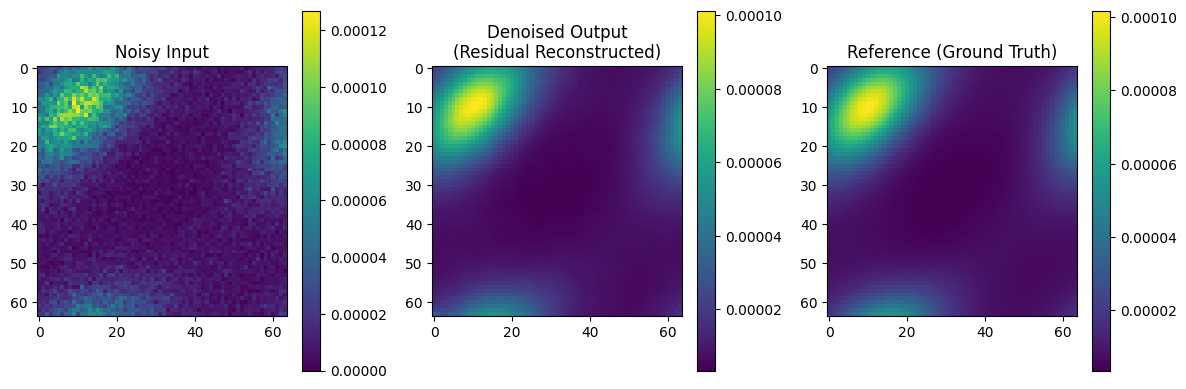

JSD between noisy and Ref: 0.009959496050937077
JSD between denoised and Ref: 0.00014755660243781293
JSD between denoised and DFT: 0.00023983929020610575
JSD between noise and DFT: 0.009987700826098357
JSD between Ref and DFT: 0.00012671965457473964


In [13]:
import numpy as np
import matplotlib.pyplot as plt
model = tf.keras.models.load_model('residual_denoiser_1M_Blob_NODFT_MD.keras')
# -----------------------------------------------------------
# 1. PREPARE DATA FOR MODEL
# -----------------------------------------------------------
# Reshape arrays to (1, H, W, D, 1) for the model
# We need 'dft_d' because the residual transform relies on it.
input_reshaped = test_d[np.newaxis, ..., np.newaxis]
dft_reshaped   = dft_d[np.newaxis, ..., np.newaxis]

# -----------------------------------------------------------
# 2. TRANSFORM INPUT (Forward Pass)
# -----------------------------------------------------------
# Convert raw noisy density -> "How far is this from DFT?"
# Uses the 'transform' function we defined earlier
input_residual = transform(input_reshaped, dft_reshaped, 'residual_noise')

# -----------------------------------------------------------
# 3. PREDICT
# -----------------------------------------------------------
# The model predicts the "Corrected Residual"
pred_residual = model.predict(input_residual)

# -----------------------------------------------------------
# 4. INVERSE TRANSFORM (Recover Density)
# -----------------------------------------------------------
# Convert "Corrected Residual" back to "Physical Density"
# Logic: Density = DFT + (Residual * sqrt(DFT))
denoised_raw = inverse_transform(pred_residual, dft_reshaped, 'residual_noise')

# Squeeze back to 3D shape (116, 116, 72)
denoised = denoised_raw[0, ..., 0]

# Safety: Density cannot be negative (physics constraint)
denoised = np.maximum(denoised, 0.0)

# -----------------------------------------------------------
# 5. VISUALIZATION & METRICS (Your snippet)
# -----------------------------------------------------------
noisy_input = test_d
true_clean = ref_d

# Dynamic z-slice (don't hardcode 64 if depth is 72)
z_mid = noisy_input.shape[2] // 2

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(noisy_input[:, :, z_mid], cmap='viridis')
plt.title("Noisy Input")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(denoised[:, :, z_mid], cmap='viridis')
plt.title("Denoised Output\n(Residual Reconstructed)")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(true_clean[:, :, z_mid], cmap='viridis')
plt.title("Reference (Ground Truth)")
plt.colorbar()

plt.tight_layout()
plt.show()

# Metric Calculation
# Ensure JSD handles small epsilons
print("JSD between noisy and Ref:", D_JS(test_d, ref_d, tol=1e-16))
print("JSD between denoised and Ref:", D_JS(denoised, ref_d, tol=1e-16))
print("JSD between denoised and DFT:", D_JS(denoised, dft_d, tol=1e-16))
print("JSD between noise and DFT:", D_JS(test_d, dft_d, tol=1e-16))
print("JSD between Ref and DFT:", D_JS(ref_d, dft_d, tol=1e-16))

In [14]:
print("here")

here


In [15]:
# --- Setup Directory Looping ---
model = tf.keras.models.load_model('residual_denoiser_1M_Blob_NODFT_MD.keras')
data_dir = '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/'
file_pattern = os.path.join(data_dir, "density_tot_vmc_mean_*.h5")
files = glob.glob(file_pattern)

results = []

# --- Processing Loop ---
for fpath in files:
    # Extract number of samples from filename using regex
    match = re.search(r'mean_(\d+)\.h5', os.path.basename(fpath))
    if not match: continue
    sample_count = int(match.group(1))
    
    with h5py.File(fpath, 'r') as f:
        test_d = np.array(f['density'])
    
    # 1. Transform & Predict
    input_reshaped = test_d[np.newaxis, ..., np.newaxis]
    dft_reshaped   = dft_d[np.newaxis, ..., np.newaxis]
    input_residual = transform(input_reshaped, dft_reshaped, 'residual_noise')
    
    pred_residual = model.predict(input_residual, verbose=0)
    
    # 2. Inverse Transform
    denoised_raw = inverse_transform(pred_residual, dft_reshaped, 'residual_noise')
    denoised = np.maximum(denoised_raw[0, ..., 0], 0.0)

    # 3. Store Metrics
    jsd_noisy = D_JS(test_d, ref_d)
    jsd_denoised = D_JS(denoised, ref_d)
    
    results.append((sample_count, jsd_noisy, jsd_denoised))

# --- Sorting & Plotting ---
# Sort results by sample count (x-axis)
results.sort(key=lambda x: x[0])
samples, noisy_jsds, denoised_jsds = zip(*results)



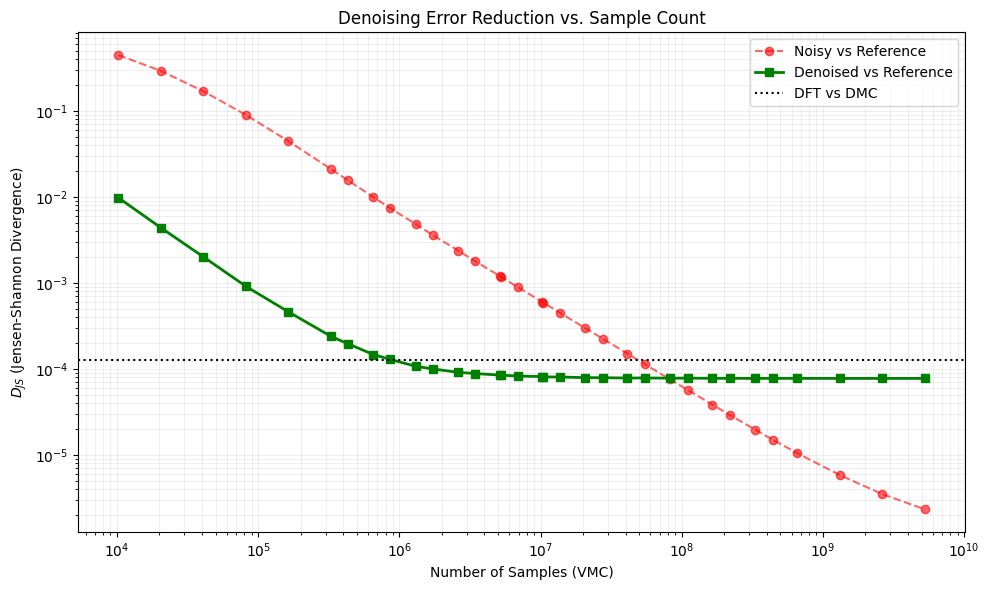

In [18]:
DFT_vs_DMC = D_JS(ref_d,dft_d)
plt.figure(figsize=(10, 6))
plt.plot(samples, noisy_jsds, 'r--o', label='Noisy vs Reference', alpha=0.6)
plt.plot(samples, denoised_jsds, 'g-s', label='Denoised vs Reference', linewidth=2)

plt.xscale('log') # Sample counts usually span orders of magnitude
plt.yscale('log') # JSD values often drop significantly
plt.axhline(DFT_vs_DMC, color="black", linestyle=":", label="DFT vs DMC")
plt.xlabel('Number of Samples (VMC)')
plt.ylabel('$D_{JS}$ (Jensen-Shannon Divergence)')
plt.title('Denoising Error Reduction vs. Sample Count')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

# Create a DataFrame with your data
data = {
    'Samples': samples,
    'Noisy_JSD': noisy_jsds,
    'Denoised_JSD': denoised_jsds
}
df = pd.DataFrame(data)

# Save to CSV
df.to_csv('diamond_jsd_data.csv', index=False)
print("Data saved to diamond_jsd_data.csv")


Data saved to diamond_jsd_data.csv
